In [1]:
import numpy as np
from dynesty import NestedSampler
from dynesty import utils as dyfunc
import matplotlib.pyplot as plt
import corner

In [2]:

# -------------------------------
# Eggbox definition
# -------------------------------

# Prior bounds
prior_min, prior_max = 0.0, 10.0 * np.pi
prior_volume = (prior_max - prior_min) ** 2  # for reference

# True evidence from the literature
true_logz = 235.856


def loglikelihood(theta):
    """
    Eggbox log-likelihood.
    theta: array of shape (2,)
    """
    x, y = theta
    return (2.0 + np.cos(x / 2.0) * np.cos(y / 2.0)) ** 5


def prior_transform(u):
    """
    Transform from unit cube [0,1]^2 to parameter space [0, 10π]^2.
    """
    x = prior_min + (prior_max - prior_min) * u[0]
    y = prior_min + (prior_max - prior_min) * u[1]
    return np.array([x, y])


# -------------------------------
# Run dynesty Nested Sampling
# -------------------------------

# 2 parameters
ndim = 2

# Set up the sampler
sampler = NestedSampler(
    loglikelihood,
    prior_transform,
    ndim,
    nlive=50,       # number of live points; increase for accuracy
    sample="rwalk",  # random-walk proposals; can try "unif", "slice"
    bound="multi",   # bounding method ("multi" good for multimodal)
)

print("Running dynesty Nested Sampling on Eggbox...")
sampler.run_nested(print_progress=True)
res = sampler.results
samples, weights = res.samples, np.exp(res.logwt - res.logz[-1])
posterior_samples = dyfunc.resample_equal(samples, weights)
# -------------------------------
# Report results
# -------------------------------
logZ, logZerr = res.logz[-1], res.logzerr[-1]

print("\n==== RESULTS ====")
print(f"dynesty estimated logZ = {logZ:.3f} ± {logZerr:.3f}")
print(f"True logZ (literature) = {true_logz:.3f}")
print(f"Error = {logZ - true_logz:.3f}")


Running dynesty Nested Sampling on Eggbox...


0it [00:00, ?it/s]

529it [00:00, 1153.18it/s, +50 | bound: 43 | nc: 1 | ncall: 9431 | eff(%):  6.172 | loglstar:   -inf < 242.999 <    inf | logz: 235.375 +/-  0.360 | dlogz:  0.001 >  0.059]


==== RESULTS ====
dynesty estimated logZ = 235.375 ± 0.392
True logZ (literature) = 235.856
Error = -0.481


In [4]:
from mins import CallableModel, MINSampler, MorphProposal
from mins.diagnostics import summarize
from mins.plotting import plot_run, plot_weight_health
from mins import StoppingCriterionConfig, StoppingPolicy

stopping = StoppingPolicy(
    criteria=(
        StoppingCriterionConfig(
            name="live_logz_error",
            tolerance=5e-3,
        ),
        StoppingCriterionConfig(
            name="remaining_fraction",
            tolerance=5e-2,
        ),
        StoppingCriterionConfig(
            name="logz_stability",
            tolerance=5e-3,
        ),
    ),
    mode="all",
    consecutive=3,
    min_iterations=10,
    stability_window=10,
)

def logprior(theta):
    x, y = theta
    if prior_min <= x <= prior_max and prior_min <= y <= prior_max:
        return -np.log(prior_volume)
    return -np.inf

model = CallableModel(
    ndim=2,
    parameter_names=("x", "y"),
    log_likelihood_fn=loglikelihood,
    log_prior_fn=logprior,
    vectorized=False,
)
proposal = MorphProposal.fit(
    posterior_samples,
    param_names=model.parameter_names,
    morph_type="2_group",
    kde_bw="silverman",
)
mins_sampler = MINSampler(
    model=model,
    proposal=proposal,
    n_live=1000,
    rng=20260725,
)

mins_result = mins_sampler.run(
    stopping=stopping,
    max_iterations=200_000,
    max_proposals_per_replacement=500_000,
    max_likelihood_calls=10_000_000,
    progress=True
)

MI pairs:   0%|          | 0/1 [00:00<?, ?it/s]

MINS nlive=1000:   0%|          | 0/200000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
diagnostics = summarize(mins_result)

print("MINS success:", mins_result.success)
print("Termination:", mins_result.termination_reason)
print(f"MINS logZ:    {mins_result.logz:.3f} ± {mins_result.logzerr:.3f}")
print(f"Dynesty logZ: {res.logz[-1]:.3f} ± {res.logzerr[-1]:.3f}")
print(f"Reference:    {true_logz:.3f}")
print("Iterations:", mins_result.niter)
print("Likelihood calls:", mins_result.n_likelihood_calls)
print("Diagnostics:", diagnostics)

for warning in mins_result.warnings:
    print("WARNING:", warning)

MINS success: False
Termination: max_likelihood_calls
MINS logZ:    235.041 ± 0.224
Dynesty logZ: 235.922 ± 0.378
Reference:    235.856
Iterations: 250
Likelihood calls: 500000
Diagnostics: RunDiagnostics(posterior_ess=6.6520420431861895, relative_posterior_ess=0.0190058344091034, proposal_acceptance_fraction=0.0005001000200040008, maximum_proposals_per_replacement=2000, thresholds_monotone=False, conservative_log_remaining=238.1690894430054)


In [ ]:
points = mins_result.all_points
weights = mins_result.posterior_weights

print(points.shape)   # (niter + nlive, ndim)
print(weights.shape)  # (niter + nlive,)
print(weights.sum())  # approximately 1
posterior_mean = np.average(
    points,
    axis=0,
    weights=weights,
)

posterior_covariance = np.cov(
    points.T,
    aweights=weights,
)


(209, 2)
(209,)
1.0000000000000013


In [ ]:
from dynesty import utils as dyfunc

equal_samples = dyfunc.resample_equal(
    points,
    weights,
    rstate=np.random.default_rng(123),
)

print(equal_samples.shape)
rng = np.random.default_rng(123)

indices = rng.choice(
    len(points),
    size=10_000,
    replace=True,
    p=weights,
)

equal_samples = points[indices]

NameError: name 'points' is not defined

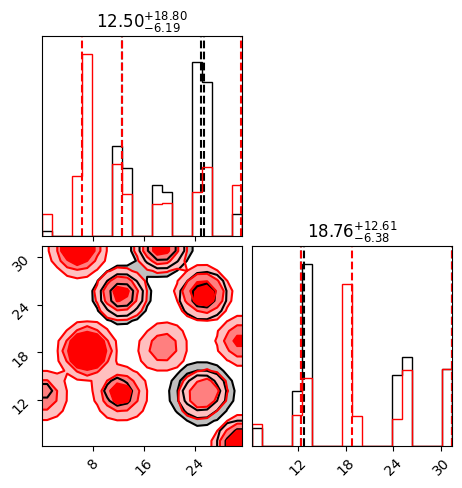

In [ ]:
fig = corner.corner(
    posterior_samples[::2,:], bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
corner.corner(
    equal_samples[::2,:],color="red", bins=20,label_kwargs = {"fontsize": 7},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    fig=fig,
    fontzise=6,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)
plt.show()